In [1]:
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def apply_v_motion_blur(img, kernel_size=15):
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[:, kernel_size // 2] = np.ones(kernel_size)
    kernel = kernel / kernel_size

    blurred = cv2.filter2D(img, -1, kernel)
    return blurred

In [5]:
def apply_h_motion_blur(img, kernel_size=15):
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[kernel_size // 2,:] = np.ones(kernel_size)
    kernel = kernel / kernel_size

    blurred = cv2.filter2D(img, -1, kernel)
    return blurred

In [19]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
in_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'train', 'normal low')
v_out_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'train', 'v_blur - cv low')
h_out_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'train', 'h_blur(opencv)')

files = os.listdir(in_path)

In [11]:
min_kernel = 15
max_kernel = 35

In [21]:
for image_name in files:
    img = cv2.imread(os.path.join(in_path, image_name))
    kernel_size = random.randint(min_kernel, max_kernel)
    blurred_img = apply_h_motion_blur(img, kernel_size=kernel_size)
    #print(f'Kernel_size: {kernel_size}')

    filename = f'{h_out_path}/{image_name}'
    cv2.imwrite(filename, blurred_img)
    print(f'Saved horizontal blurred plate: {filename}')

    #plt.imshow(cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB))
    #plt.axis('off')
    #plt.show()

Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/1.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/100.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/1000.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10000.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10001.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10002.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10003.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10004.jpg
Saved vertically blurred plate: C:\Thesis\LiPAD\data\all\experiment2\train\h_blur(opencv)/10005.jpg
Saved vert

In [21]:
min_kernel = 5
max_kernel = 20

In [23]:
for image_name in files:
    img = cv2.imread(os.path.join(in_path, image_name))
    kernel_size = random.randint(min_kernel, max_kernel)
    blurred_img = apply_v_motion_blur(img, kernel_size=kernel_size)

    filename = f'{v_out_path}/{image_name}'
    cv2.imwrite(filename, blurred_img)
    #print(f'Saved horizontally blurred plate: {filename}')

    #plt.imshow(cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB))
    #plt.axis('off')
    #plt.show()

In [30]:
min_kernel = 40
max_kernel = 80

In [22]:
in_path = os.path.join(ROOT_DIR, 'data', 'experiment', 'enhanced')
h_out_path = os.path.join(ROOT_DIR, 'data', 'experiment', 'h_blur cv enhanced')
for image_name in files:
    img = cv2.imread(os.path.join(in_path, image_name))
    kernel_size = random.randint(min_kernel, max_kernel)
    blurred_img = apply_h_motion_blur(img, kernel_size=kernel_size)

    filename = f'{h_out_path}/{image_name}'
    cv2.imwrite(filename, blurred_img)
    #print(f'Saved horizontally blurred plate: {filename}')

    #plt.imshow(cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB))
    #plt.axis('off')
    #plt.show()

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\filter.dispatch.cpp:1528: error: (-215:Assertion failed) !_src.empty() in function 'cv::filter2D'


# Kornia

In [7]:
import torch
import kornia
from PIL import Image
import torchvision.transforms.functional as TF

In [15]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
in_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'valid', 'normal')
v_out_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'valid', 'v_blur kornia')
h_out_path = os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'train', 'h_blur')

files = os.listdir(in_path)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
min_kernel, max_kernel = 7, 51
min_angle, max_angle = 85, 95

### Horizontal Blur

In [22]:
for image_name in files:
    img_path = os.path.join(in_path, image_name)
    img = Image.open(img_path).convert("RGB")  
    img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)  
    
    kernel_size = random.choice([k for k in range(min_kernel, max_kernel + 1) if k % 2 == 1])

    h_blur = kornia.filters.MotionBlur(kernel_size, 0, 0)
    output = h_blur(img_tensor)

    output_img = output.squeeze().permute(1, 2, 0).cpu().numpy()
    output_img = (output_img * 255).clip(0, 255).astype(np.uint8)

    filename = os.path.join(h_out_path, image_name)
    cv2.imwrite(filename, cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))
    
    #print(f'Saved horizontally blurred plate: {filename}')

KeyboardInterrupt: 

### Vertical Blur

In [17]:
for image_name in files:
    img_path = os.path.join(in_path, image_name)
    img = Image.open(img_path).convert("RGB")  
    img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)  
    
    kernel_size = random.choice([k for k in range(min_kernel, max_kernel + 1) if k % 2 == 1])
    direction = random.randint(min_angle, max_angle)

    v_blur = kornia.filters.MotionBlur(kernel_size, direction, 0)
    output = v_blur(img_tensor)

    output_img = output.squeeze().permute(1, 2, 0).cpu().numpy()
    output_img = (output_img * 255).clip(0, 255).astype(np.uint8)

    filename = os.path.join(v_out_path, image_name)
    cv2.imwrite(filename, cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))
    
    #print(f'Saved vertically blurred plate: {filename}')

In [54]:
in_path = os.path.join(ROOT_DIR, 'data', 'experiment', 'enhanced')
v_out_path = os.path.join(ROOT_DIR, 'data', 'experiment', 'v_blur kornia enhanced')
h_out_path = os.path.join(ROOT_DIR, 'data', 'experiment', 'h_blur kornia enhanced')

files = os.listdir(in_path)

In [21]:
for image_name in files:
    img_path = os.path.join(in_path, image_name)
    img = Image.open(img_path).convert("RGB")  
    img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)  
    
    kernel_size = random.choice([k for k in range(min_kernel, max_kernel + 1) if k % 2 == 1])

    v_blur = kornia.filters.MotionBlur(kernel_size, 90, 0)
    output = v_blur(img_tensor)

    output_img = output.squeeze().permute(1, 2, 0).cpu().numpy()
    output_img = (output_img * 255).clip(0, 255).astype(np.uint8)

    filename = os.path.join(v_out_path, image_name)
    cv2.imwrite(filename, cv2.cvtColor(output_img, cv2.COLOR_RGB2BGR))
    
    #print(f'Saved vertically blurred plate: {filename}')

In [217]:
img = Image.open(os.path.join(ROOT_DIR, 'data', 'all', 'experiment2', 'train', 'normal', '16901.jpg'))
img_tensor = TF.to_tensor(img).unsqueeze(0)

In [231]:
h_blur = kornia.filters.MotionBlur(7, 85, 0) # 11-31, 0-30, -1-1
output = h_blur(img_tensor)

In [233]:
def show_img(tensor, title="Image"):
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)

    # Clamp values in case the tensor contains out-of-range values
    tensor = tensor.clamp(0, 1)

    # Convert to numpy
    img_np = TF.to_pil_image(tensor)

    plt.figure()
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")
    plt.show()

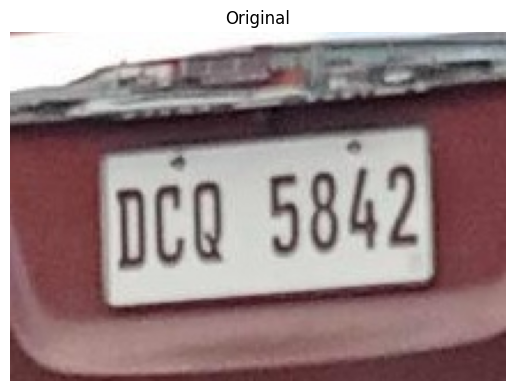

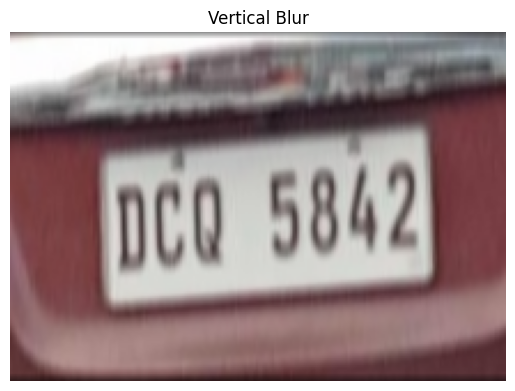

In [235]:
show_img(img_tensor, "Original")
show_img(output, "Vertical Blur")

In [58]:
torch.cuda.empty_cache()